<a href="https://colab.research.google.com/github/keandres12/MineriaDeDatos/blob/Entrega3/Entrega3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MINERÍA DE DATOS — EVALUACIÓN FINAL
## Análisis Exploratorio y Modelación Predictiva: Mercado Chileno vs Crudo Internacional

* **Integrante:** Kevin Castro
* **Asignatura:** Minería de Datos

### 1. Justificación del Dataset y Contexto Económico
Este proyecto analiza la relación histórica entre los dos marcadores de petróleo crudo más importantes del mundo, **Brent Crude** y **WTI**, frente al precio minorista del combustible en Chile.

A nivel metodológico, abordaremos el problema mediante dos enfoques:
1. **Regresión Lineal (Modelo Paramétrico):** Para evaluar la tendencia global y calcular la elasticidad del precio local respecto a los commodities.
2. **Árbol de Decisión (Modelo No Paramétrico):** Para capturar las estructuras escalonadas del mercado chileno, fuertemente influenciado por el **MEPCO** (Mecanismo de Estabilización de Precios de los Combustibles), el cual actúa amortiguando y ralentizando los impactos directos de los shocks internacionales.


# 1. Importación de Librerías


In [2]:
# ====================================================================
# FASE 1: IMPORTACIÓN DE LIBRERÍAS Y CONFIGURACIÓN DEL ENTORNO
# ====================================================================
!pip install yfinance -q

import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from google.colab import drive
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.metrics import r2_score, classification_report, confusion_matrix

# Configuración global de visualización de números
pd.set_option('display.float_format', lambda x: '%.2f' % x)

# Conectar Google Drive de forma segura
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## FASE 2: CARGA Y PREPROCESAMIENTO DE DATOS (DATA CLEANING)
En esta fase cargamos el dataset unificado gigante, resolvemos los valores nulos mediante técnicas avanzadas de series de tiempo y aplicamos filtros de seguridad para eliminar anomalías de digitación.


# 2. Carga y Estructuración de Datos


In [3]:
# 2. Definir la ruta exacta de tu archivo ya consolidado
ruta_archivo = '/content/drive/MyDrive/dataset/dataset_final_unido.csv'

print("Cargando el super-dataset... (esto puede tomar un minuto o dos)")

# 3. Leer el archivo CSV
# Usamos low_memory=False porque al ser un archivo gigante, ayuda a que Pandas
# no se confunda con los tipos de datos de cada columna.
df = pd.read_csv(ruta_archivo, low_memory=False)

# 4. Ver el tamaño y las primeras filas para confirmar
print(f"\n¡Dataset cargado exitosamente! Total de filas: {len(df)}")

# df.info() te mostrará el tipo de dato de cada columna y cuántos nulos hay
df.info()

# Mostrar las primeras 5 filas
df.head()

Cargando el super-dataset... (esto puede tomar un minuto o dos)

¡Dataset cargado exitosamente! Total de filas: 8925675
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8925675 entries, 0 to 8925674
Data columns (total 19 columns):
 #   Column               Dtype  
---  ------               -----  
 0   id                   object 
 1   razon_social         object 
 2   distribuidor         object 
 3   direccion_calle      object 
 4   direccion_numero     float64
 5   comuna               object 
 6   region               object 
 7   precio               float64
 8   fecha_actualizacion  object 
 9   combustible          object 
 10  latitud              object 
 11  longitud             object 
 12  unidad_cobro         object 
 13  atencion             object 
 14  hora_actualizacion   object 
 15  es_electrolinera     float64
 16  es_gasolinera        float64
 17  Precio_Brent_USD     float64
 18  Precio_WTI_USD       float64
dtypes: float64(6), object(13)
memory usage: 1.3+ GB


,id,razon_social,distribuidor,direccion_calle,direccion_numero,comuna,region,precio,fecha_actualizacion,combustible,latitud,longitud,unidad_cobro,atencion,hora_actualizacion,es_electrolinera,es_gasolinera,Precio_Brent_USD,Precio_WTI_USD
0,co1312002,Sociedad Herrera Bravo Ltda,COPEC,Avenida Irarrázaval,5277.00,Ñuñoa,Metropolitana,759.00,2012-01-01,Gasolina 93,"-33,4540062109273","-70,57525992393493",NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,pb630302,Distribuidora Dagnino Giacobbe y Cía. Ltda. 7...,Sin Bandera,Camino a Codegua Km,1.00,Chimbarongo,Gral. Bernardo O'Higgins,612.00,2012-12-13,Petroleo Diesel,"-34,71739081954427","-71,02941691875458",NaN,NaN,NaN,NaN,NaN,107.91,85.89
2,co120501,SOCIEDAD COMERCIAL IBAï¿½EZ Y NEGRON LTDA.,COPEC,"PANAMERICANA NORTE KM 1750, EX S. V",0.00,Pozo Almonte,Tarapacá,777.00,2012-12-06,Gasolina 95,"-21,09225805724834","-69,5928230881691",NaN,NaN,NaN,NaN,NaN,107.03,86.26
3,te1312301,Gilberto Zamorano Vega,SHELL,Holanda,2808.00,Providencia,Metropolitana,790.00,2012-12-06,Gasolina 97,"-33,44420837761395","-70,59720039367676",NaN,NaN,NaN,NaN,NaN,107.03,86.26
4,co1313201,PATRICIO REYES INFANTE Y CIA LTDA,COPEC,Av. Vitacura,6380.00,Vitacura,Metropolitana,873.00,2012-09-06,Gasolina 97,"-33,38974288164123","-70,57051241397858",NaN,NaN,NaN,NaN,NaN,113.49,95.53


# Fase de Limpieza y Preprocesamiento

In [4]:
# 1. TRATAR COLUMNAS INFORMATIVAS (Rellenar en lugar de borrar)
columnas_texto = ['unidad_cobro', 'atencion', 'hora_actualizacion']
df[columnas_texto] = df[columnas_texto].fillna('No Informado')

columnas_bandera = ['es_electrolinera', 'es_gasolinera']
df[columnas_bandera] = df[columnas_bandera].fillna(0)

# Reemplazar nulos en la columna 'razon_social' por 'no informa'
df['razon_social'] = df['razon_social'].fillna('no informa')

# 2. ORDENAR Y APLICAR FFILL (Precios Locales e Internacionales)
df = df.sort_values(by=['id', 'combustible', 'fecha_actualizacion'])
print("Rellenando precios locales por estación... (FFill agrupado)")
df['precio'] = df.groupby(['id', 'combustible'])['precio'].ffill()

df = df.sort_values(by='fecha_actualizacion')
columnas_petroleo = ['Precio_Brent_USD', 'Precio_WTI_USD']
df[columnas_petroleo] = df[columnas_petroleo].ffill()

# 3. ELIMINAR FILAS SIN HISTORIAL INICIAL
columnas_cruciales = ['precio', 'Precio_Brent_USD', 'Precio_WTI_USD']
df_limpio = df.dropna(subset=columnas_cruciales)

# 4. ELIMINAR COLUMNAS QUE NO APORTAN AL MODELO PREDICTIVO
columnas_a_eliminar = ['id', 'latitud', 'direccion_numero', 'direccion_calle',
                       'longitud', 'unidad_cobro', 'atencion', 'hora_actualizacion',
                       'es_electrolinera', 'es_gasolinera']
df_limpio = df_limpio.drop(columns=columnas_a_eliminar)

# 5. FILTROS DE SEGURIDAD (Rango lógico de precios en Chile)
df_limpio = df_limpio[(df_limpio['precio'] >= 630) & (df_limpio['precio'] <= 1650)]

# 6. ORDENAR CRONOLÓGICAMENTE FINAL Y REINICIAR ÍNDICE
df_limpio = df_limpio.sort_values(by='fecha_actualizacion', ascending=True).reset_index(drop=True)

print(f"\n¡Proceso de limpieza completado!")
print(f"Filas originales: {len(df)} | Filas resultantes: {len(df_limpio)}")
print(f"Nulos remanentes:\n{df_limpio.isnull().sum()}")

Rellenando precios locales por estación... (FFill agrupado)

¡Proceso de limpieza completado!
Filas originales: 8925675 | Filas resultantes: 7341046
Nulos remanentes:
razon_social           0
distribuidor           0
comuna                 0
region                 0
precio                 0
fecha_actualizacion    0
combustible            0
Precio_Brent_USD       0
Precio_WTI_USD         0
dtype: int64


# Visualizamos las primeras 5 filas

In [ ]:
df_limpio.head()

# Visualizamos las ultimas 5 filas

In [ ]:
df_limpio.tail()

# Devuelve la cantidad de filas y columnas respectivamente

In [10]:
df_limpio.shape

(7341046, 9)

# Observamos la columna y sus tipos de datos

In [11]:
df_limpio.dtypes

,0
razon_social,object
distribuidor,object
comuna,object
region,object
precio,float64
fecha_actualizacion,datetime64[ns]
combustible,object
Precio_Brent_USD,float64
Precio_WTI_USD,float64


# Mostramos los nombres de las columnas

In [15]:
df_limpio.columns

Index(['razon_social', 'distribuidor', 'comuna', 'region', 'precio',
       'fecha_actualizacion', 'combustible', 'Precio_Brent_USD',
       'Precio_WTI_USD'],
      dtype='object')

In [24]:
df_limpio[['precio', 'Precio_Brent_USD', 'Precio_WTI_USD']].describe()

,precio,Precio_Brent_USD,Precio_WTI_USD
count,7341046.00,7341046.00,7341046.00
mean,901.21,75.71,69.95
std,210.12,23.33,21.38
min,630.00,19.33,-37.63
25%,760.00,58.35,52.61
50%,833.00,72.88,68.19
75%,981.00,94.67,88.07
max,1650.00,127.98,123.70


# Análisis Exploratorio de Datos

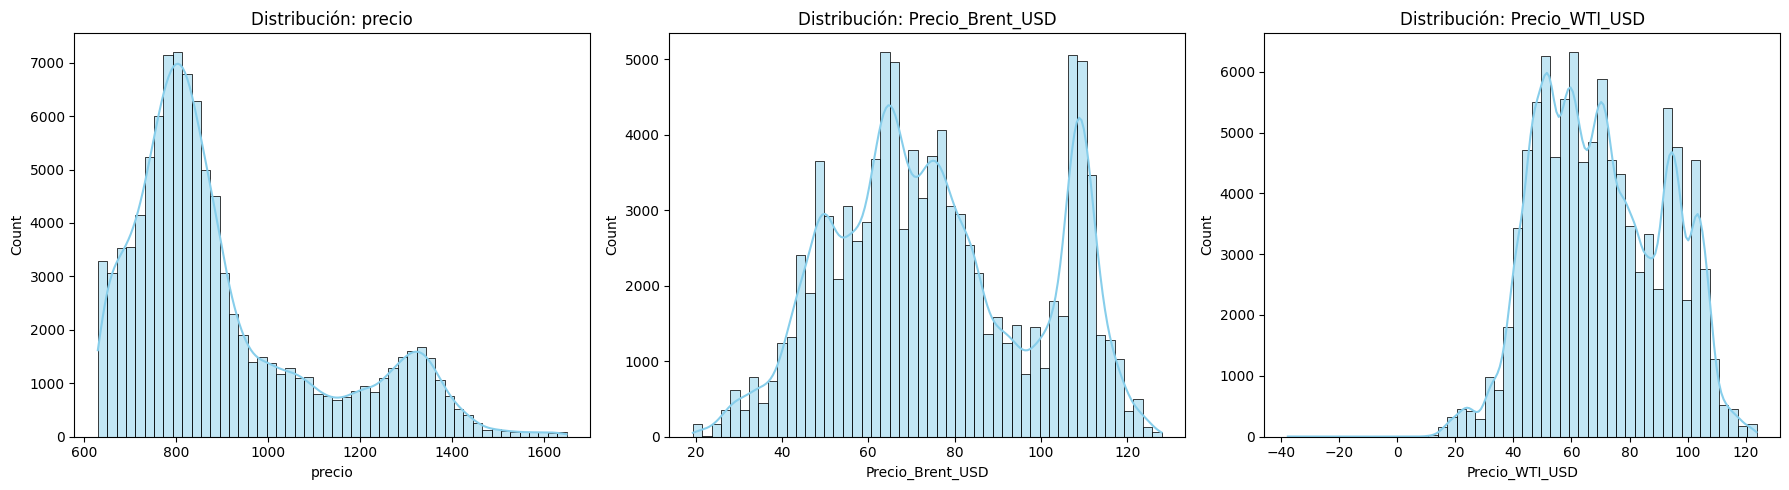

In [5]:
cols_numericas = ['precio', 'Precio_Brent_USD', 'Precio_WTI_USD']
plt.figure(figsize=(18, 5))

for i, col in enumerate(cols_numericas, 1):
    plt.subplot(1, 3, i)
    sns.histplot(df_limpio[col].sample(100000, random_state=42), kde=True, bins=50, color='skyblue')
    plt.title(f'Distribución: {col}')

plt.tight_layout()
plt.show()

# Grafico

In [17]:
cols_numericas = [
    'precio','Precio_Brent_USD','Precio_WTI_USD'
]

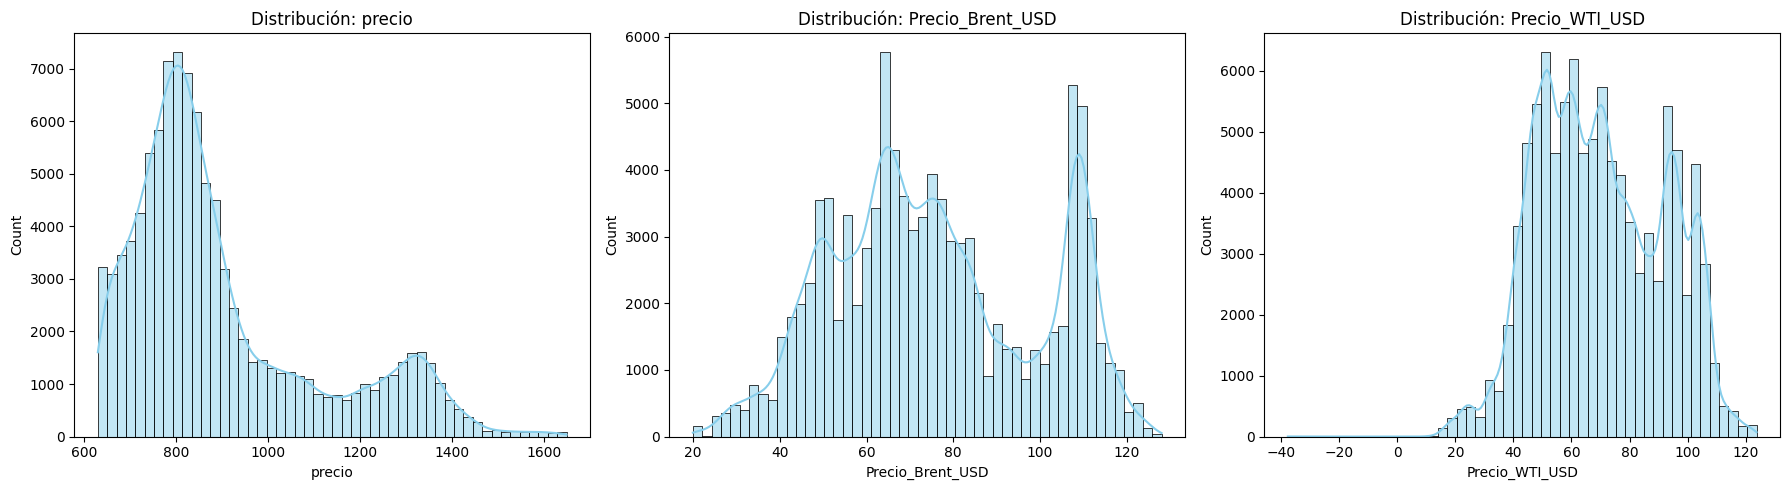

In [18]:
# Cambiamos el tamaño para que sea 1 fila y 3 columnas (horizontal)
plt.figure(figsize=(18, 5))

for i, col in enumerate(cols_numericas, 1):
    plt.subplot(1, 3, i)

    # Usamos .sample(100000) para que dibuje el gráfico rápido sin que Colab explote.
    # El parámetro bins=50 agrupa las barras para que se vea más limpio.
    sns.histplot(df_limpio[col].sample(100000), kde=True, bins=50, color='skyblue')

    plt.title(f'Distribución: {col}')

plt.tight_layout()
plt.show()

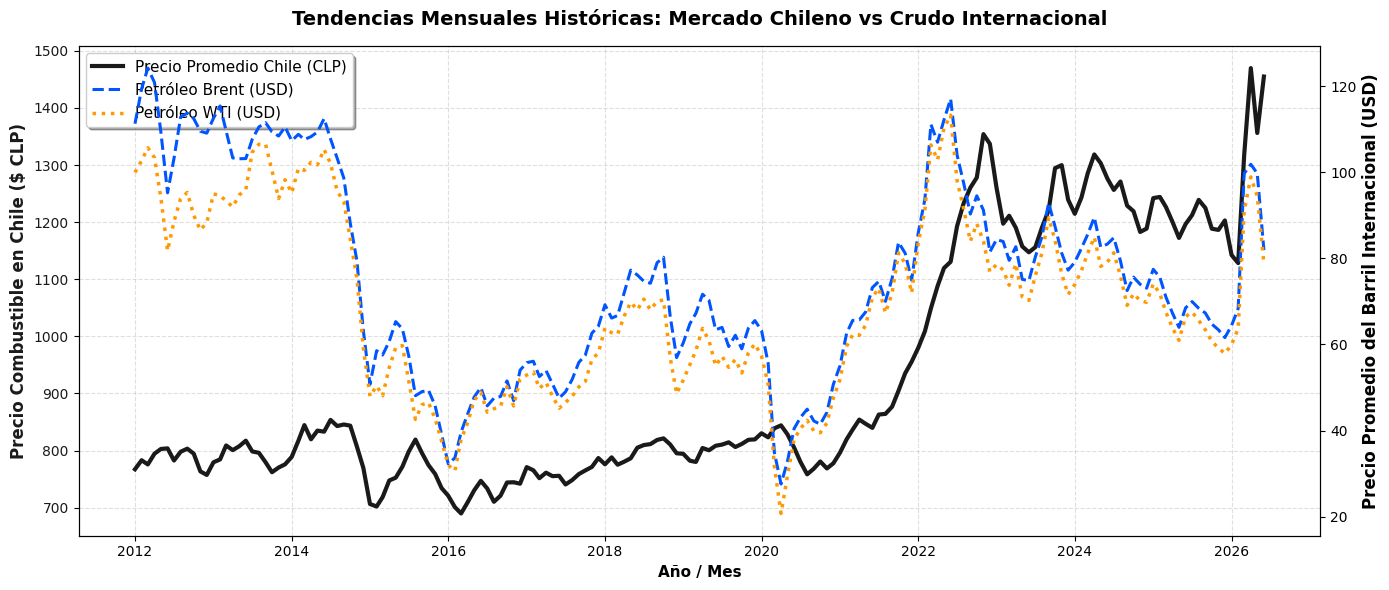

In [19]:
# 1. Asegurar formato de fecha
df_limpio['fecha_actualizacion'] = pd.to_datetime(df_limpio['fecha_actualizacion'])

# 2. Agrupar por MES usando resample (calcula el promedio mensual de los precios)
df_mensual_plot = df_limpio.set_index('fecha_actualizacion').resample('MS').agg({
    'precio': 'mean',
    'Precio_Brent_USD': 'mean',
    'Precio_WTI_USD': 'mean'
}).sort_index()

# 3. Configuración del lienzo
fig, ax1 = plt.subplots(figsize=(14, 6))

# --- PALETA DE COLORES DE ALTO CONTRASTE ---
color_chile = '#1A1A1A'  # Negro Carbón (Para el mercado local)
color_brent = '#0055FF'  # Azul Eléctrico
color_wti = '#FF9900'    # Naranja Neón / Ámbar

# --- EJE IZQUIERDO: Precio Mensual Promedio en Chile (CLP) ---
ax1.plot(df_mensual_plot.index, df_mensual_plot['precio'],
         color=color_chile, linestyle='-', linewidth=3.0, label='Precio Promedio Chile (CLP)')

ax1.set_xlabel('Año / Mes', fontsize=11, fontweight='bold')
ax1.set_ylabel('Precio Combustible en Chile ($ CLP)', color=color_chile, fontsize=12, fontweight='bold')
ax1.tick_params(axis='y', labelcolor=color_chile)
ax1.grid(True, linestyle='--', alpha=0.4)

# --- EJE DERECHO: Precios Mensuales Internacionales (USD) ---
ax2 = ax1.twinx()

# Brent: Línea segmentada
ax2.plot(df_mensual_plot.index, df_mensual_plot['Precio_Brent_USD'],
         color=color_brent, linestyle='--', linewidth=2.2, label='Petróleo Brent (USD)')

# WTI: Línea de puntos
ax2.plot(df_mensual_plot.index, df_mensual_plot['Precio_WTI_USD'],
         color=color_wti, linestyle=':', linewidth=2.5, label='Petróleo WTI (USD)')

ax2.set_ylabel('Precio Promedio del Barril Internacional (USD)', color='black', fontsize=12, fontweight='bold')
ax2.tick_params(axis='y', labelcolor='black')

# 4. UNIFICAR LEYENDAS
lineas_1, etiquetas_1 = ax1.get_legend_handles_labels()
lineas_2, etiquetas_2 = ax2.get_legend_handles_labels()
ax1.legend(lineas_1 + lineas_2, etiquetas_1 + etiquetas_2,
           loc='upper left', fontsize=11, facecolor='white', frameon=True, shadow=True)

plt.title('Tendencias Mensuales Históricas: Mercado Chileno vs Crudo Internacional', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

   REPORTE DE ALZAS Y CAÍDAS MENSUALES (MoM)

--- Mercado Local: Combustible Chile (CLP) ---
Mayor ALZA en un solo mes:    +16.74%  (Ocurrió en: 2026-03)
Mayor CAÍDA en un solo mes:   -8.22%
Promedio de variación mensual: 0.41%

--- Mercado Internacional: Brent (USD) ---
Mayor ALZA en un solo mes:    +45.93%  (Ocurrió en: 2026-03)
Mayor CAÍDA en un solo mes:   -37.31%
Promedio de variación mensual: 0.23%

--- Mercado Internacional: WTI (USD) ---
Mayor ALZA en un solo mes:    +43.00%  (Ocurrió en: 2026-03)
Mayor CAÍDA en un solo mes:   -37.65%
Promedio de variación mensual: 0.36%



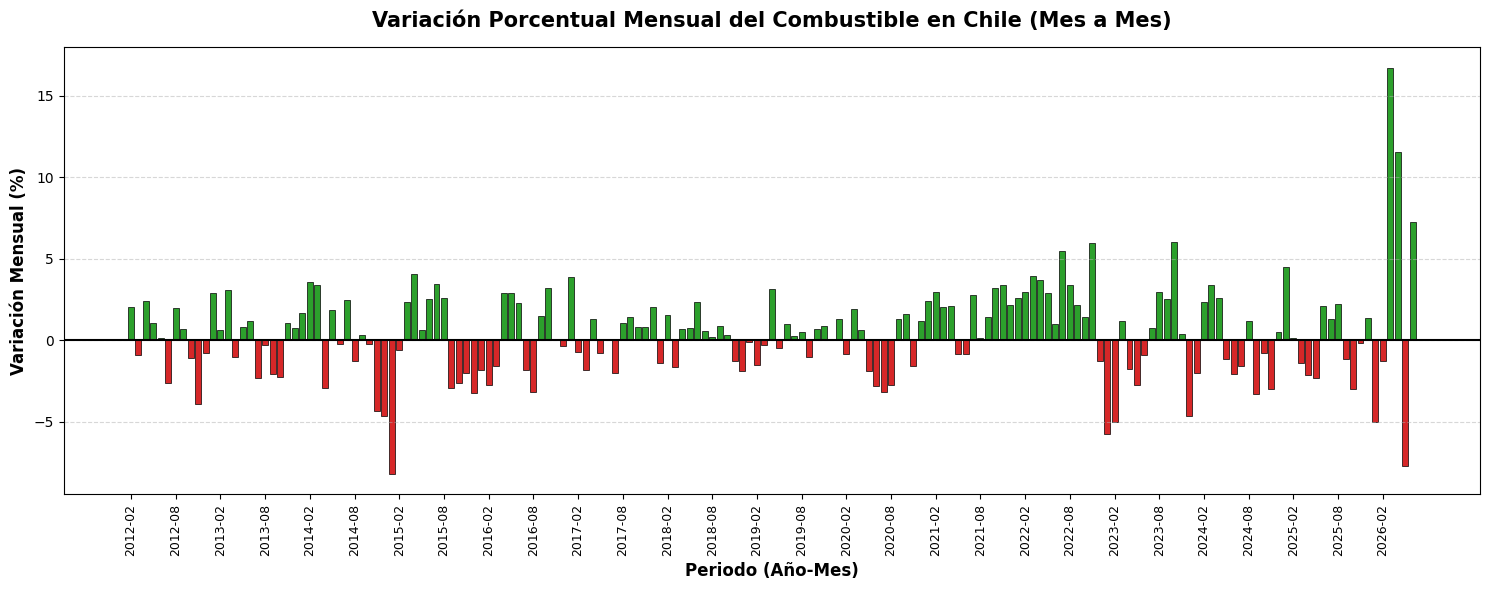

In [20]:
# 1. Preparar el dataset: Asegurar fecha y ponerla como índice
df_mes = df_limpio.copy()
df_mes['fecha_actualizacion'] = pd.to_datetime(df_mes['fecha_actualizacion'])
df_mes = df_mes.set_index('fecha_actualizacion')

# 2. Agrupar por MES ('ME' = Month End) calculando el promedio
df_mensual = df_mes[['precio', 'Precio_Brent_USD', 'Precio_WTI_USD']].resample('ME').mean()

# 3. Calcular la variación porcentual mensual (* 100)
# Eliminar la primera fila (NaN) porque no tiene un mes previo con el cual compararse
df_var_mensual = df_mensual.pct_change().dropna() * 100

print("==========================================================")
print("   REPORTE DE ALZAS Y CAÍDAS MENSUALES (MoM)")
print("==========================================================\n")

columnas_analisis = {
    'precio': 'Mercado Local: Combustible Chile (CLP)',
    'Precio_Brent_USD': 'Mercado Internacional: Brent (USD)',
    'Precio_WTI_USD': 'Mercado Internacional: WTI (USD)'
}

for col, nombre in columnas_analisis.items():
    alza_max = df_var_mensual[col].max()
    caida_max = df_var_mensual[col].min()
    promedio_mensual = df_var_mensual[col].mean()

    # Encontrar exactamente en qué mes ocurrió la mayor alza
    mes_peor_alza = df_var_mensual[col].idxmax().strftime('%Y-%m')

    print(f"--- {nombre} ---")
    print(f"Mayor ALZA en un solo mes:    +{alza_max:.2f}%  (Ocurrió en: {mes_peor_alza})")
    print(f"Mayor CAÍDA en un solo mes:   {caida_max:.2f}%")
    print(f"Promedio de variación mensual: {promedio_mensual:.2f}%\n")


# =====================================================================
# GRÁFICO: VARIACIÓN MENSUAL DEL COMBUSTIBLE EN CHILE
# =====================================================================
plt.figure(figsize=(15, 6))

# Crear lista de colores: Rojo si bajó el precio (< 0), Verde si subió (> 0)
colores = ['#d62728' if val < 0 else '#2ca02c' for val in df_var_mensual['precio']]
meses_etiquetas = df_var_mensual.index.strftime('%Y-%m')

# Gráfico de barras
plt.bar(meses_etiquetas, df_var_mensual['precio'], color=colores, edgecolor='black', linewidth=0.5)

plt.title('Variación Porcentual Mensual del Combustible en Chile (Mes a Mes)', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Periodo (Año-Mes)', fontsize=12, fontweight='bold')
plt.ylabel('Variación Mensual (%)', fontsize=12, fontweight='bold')

# Solución para el texto encimado en el eje X: Mostrar solo 1 de cada 6 meses
posiciones_ticks = np.arange(0, len(meses_etiquetas), 6)
plt.xticks(posiciones_ticks, meses_etiquetas[posiciones_ticks], rotation=90, fontsize=9)

# Línea horizontal en cero para separar alzas de caídas
plt.axhline(0, color='black', linewidth=1.5)

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Modelo de regresion lineal
arbol de decision
puntos de interseccion
grafico del ultimo año
contexto